In [40]:
import numpy as np
import pyedflib
from scipy import signal
import pywt
import matplotlib.pyplot as plt
import pandas as pd

# Настройка шрифтов для корректного отображения символов
plt.rcParams["font.family"] = ["SimHei", "Microsoft YaHei"]
plt.rcParams["axes.unicode_minus"] = False

In [41]:
# Основные параметры
EDF_FILE = "eeg18.edf"
LOWPASS_FREQ = 60

# Чтение файла
f = pyedflib.EdfReader(EDF_FILE)

n_channels = f.signals_in_file
sfreq = f.getSampleFrequency(0)
duration = f.getFileDuration()

# Считывание всех каналов
eeg_data = np.zeros((n_channels, f.getNSamples()[0]))
for i in range(n_channels):
    eeg_data[i, :] = f.readSignal(i)

# Временная ось
times = np.arange(eeg_data.shape[1]) / sfreq

# Вывод информации
print("Чтение файла завершено успешно!")
print(f"Количество каналов: {n_channels}")
print(f"Частота дискретизации: {sfreq} Гц")
print(f"Общая длительность: {duration:.1f} с")
print(f"Размер данных: {eeg_data.shape}")

f.close()

Чтение файла завершено успешно!
Количество каналов: 21
Частота дискретизации: 256.0 Гц
Общая длительность: 3651.0 с
Размер данных: (21, 934656)


In [42]:
# Интервал приступа для файла eeg18.edf
SEIZURE_START = 20
SEIZURE_END = 50

start_idx = np.argmin(np.abs(times - SEIZURE_START))
end_idx = np.argmin(np.abs(times - SEIZURE_END))

seizure_data = eeg_data[:, start_idx:end_idx]
seizure_times = times[start_idx:end_idx]

print(f"Выделен интервал приступа: {SEIZURE_START} – {SEIZURE_END} с")

Выделен интервал приступа: 20 – 50 с


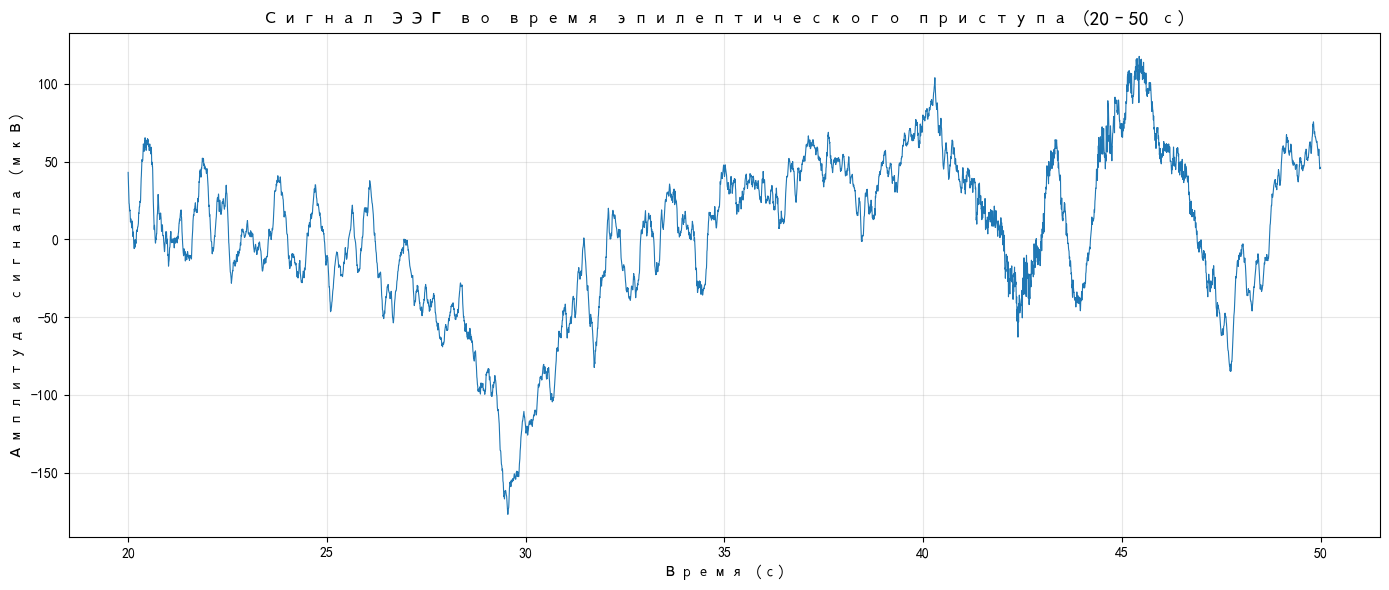

In [43]:
plt.figure(figsize=(14, 6))
plt.plot(seizure_times, seizure_data[0], color="#1f77b4", linewidth=0.8)
plt.title(f"Сигнал ЭЭГ во время эпилептического приступа ({SEIZURE_START}–{SEIZURE_END} с)", fontsize=14)
plt.xlabel("Время (с)", fontsize=12)
plt.ylabel("Амплитуда сигнала (мкВ)", fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [44]:
# Усреднение по всем каналам ЭЭГ
eeg_avg = np.mean(eeg_data, axis=0)

print("Усреднение по каналам выполнено!")
print(f"Размер усреднённого сигнала: {eeg_avg.shape}")

Усреднение по каналам выполнено!
Размер усреднённого сигнала: (934656,)


In [45]:
# Фильтр Баттерворта нижних частот
nyq = 0.5 * sfreq
cutoff_norm = LOWPASS_FREQ / nyq
b, a = signal.butter(4, cutoff_norm, btype="low")

# Применение фильтра
eeg_filtered = signal.filtfilt(b, a, eeg_avg)

# Выделение отфильтрованного участка приступа
filt_seizure = eeg_filtered[start_idx:end_idx]
filt_times = seizure_times

print("Фильтрация сигнала завершена!")

Фильтрация сигнала завершена!


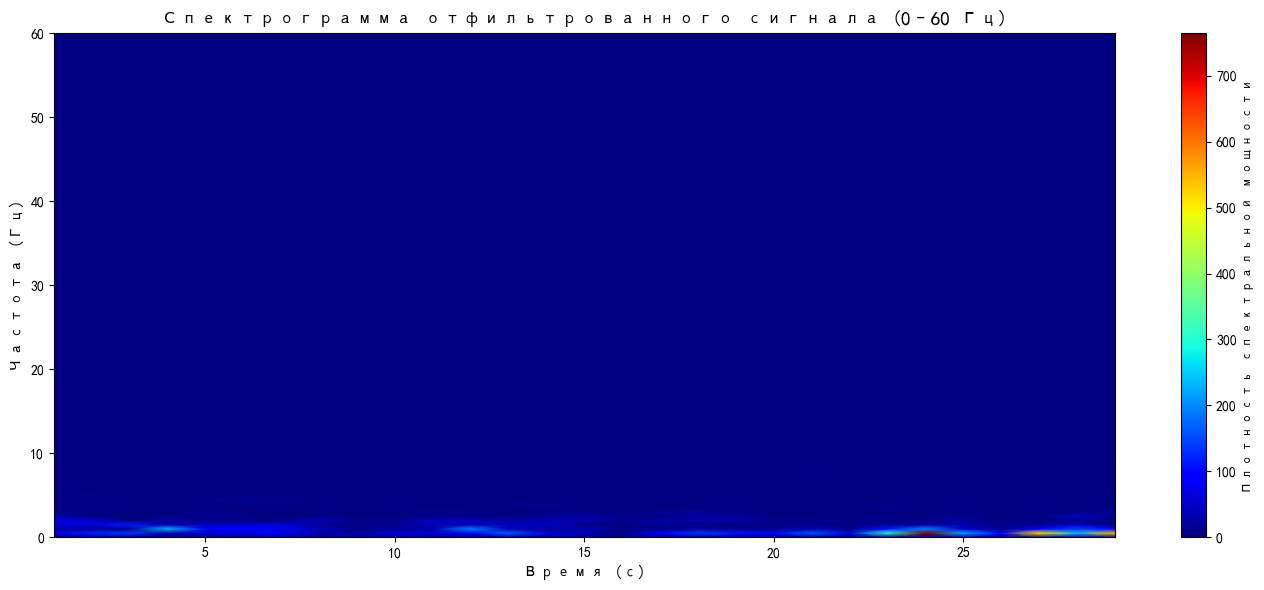

In [46]:
plt.figure(figsize=(14, 6))
f, t, Sxx = signal.spectrogram(filt_seizure, fs=sfreq, nperseg=512, noverlap=256)

plt.pcolormesh(t, f, Sxx, shading="gouraud", cmap="jet")
plt.ylim(0, LOWPASS_FREQ)
plt.colorbar(label="Плотность спектральной мощности")
plt.title("Спектрограмма отфильтрованного сигнала (0–60 Гц)", fontsize=14)
plt.xlabel("Время (с)", fontsize=12)
plt.ylabel("Частота (Гц)", fontsize=12)
plt.tight_layout()
plt.show()

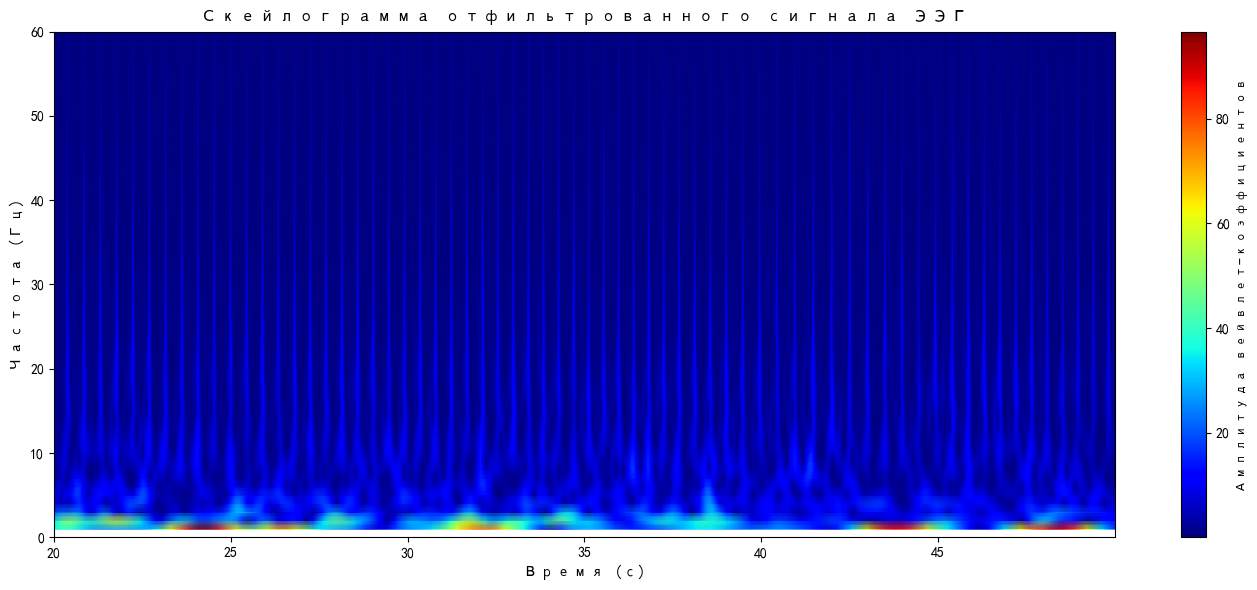

In [47]:
plt.figure(figsize=(14, 6))
wavelet = "cmor1.5-1.0"
scales = pywt.scale2frequency(wavelet, np.arange(1, 128)) * sfreq

coef, freq = pywt.cwt(filt_seizure, scales=scales, wavelet=wavelet, sampling_period=1/sfreq)

plt.pcolormesh(filt_times, freq, np.abs(coef), shading="gouraud", cmap="jet")
plt.ylim(0, LOWPASS_FREQ)
plt.colorbar(label="Амплитуда вейвлет-коэффициентов")
plt.title("Скейлограмма отфильтрованного сигнала ЭЭГ", fontsize=14)
plt.xlabel("Время (с)", fontsize=12)
plt.ylabel("Частота (Гц)", fontsize=12)
plt.tight_layout()
plt.show()

In [48]:
print("="*60)
print("ЗАДАНИЕ ВЫПОЛНЕНО")
print("1. Чтение EDF-файла")
print("2. Выделение интервала приступа")
print("3. Построение графика ЭЭГ")
print("4. Усреднение по каналам")
print("5. Фильтрация ниже 60 Гц")
print("6. Построение спектрограммы")
print("7. Построение скейлограммы (вейвлет-преобразование)")
print("="*60)

ЗАДАНИЕ ВЫПОЛНЕНО
1. Чтение EDF-файла
2. Выделение интервала приступа
3. Построение графика ЭЭГ
4. Усреднение по каналам
5. Фильтрация ниже 60 Гц
6. Построение спектрограммы
7. Построение скейлограммы (вейвлет-преобразование)
